# Multiobjective optimization --  3 cost terms

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/04 09:34:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/04 09:34:26 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
2025-12-04 09:34:27,406 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/12/04 09:34:28 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-12-04 09:34:29,111 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-12-04 09:34:31,417 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-12-04 09:34:31,417 INFO     >>> Reading claims file: /Users/Charles/DATA/ckd/ckd_claims
2025-12-04 09:34

# Load Data

In [3]:
df_2018 = spark.read.format("parquet").load( "0917_2017_18_with_2017_cost.parquet")
df_og = df_2018.toPandas()
df_og.shape,df_og.columns

((33542, 95),
 Index(['ENROLID', 'annual_cost_2017', 'highcost_gt_50000_2017',
        'highcost_gt_75000_2017', 'highcost_gt_100000_2017',
        'highcost_gt_200000_2017', 'highcost_gt_300000_2017',
        'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'INCOME_LEVEL',
        'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000',
        'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000',
        'highcost_gt_400000', 'highcost_gt_500000', 'AGEGRP', 'SEX', 'REGION',
        'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia',
        'has_Hyperlipidemia', 'has_Acute_Kidney_Failure',
        'has_Hyperparathyroidism', 'has_Kidney_Transplant',
        'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy',
        'has_Hypothyroidism', 'has_Sleep_Apnea', 'stage_2017', 'util_2017',
        'Antihyperlipidemic Drugs, NEC (THRCLS_53)',
        'Cardiac, Beta Blockers (THRCLS_51)',
        'Cardiac, Calcium Channel (THRCLS_52)',
        'Psychot

# Feature groups, define high cost and train-test-split

In [4]:
import importlib
import model_pipeline
importlib.reload(model_pipeline)
BIN_FLAG_COLUMNS = model_pipeline.get_bin_flag_columns(df_og) +['lab_monitoring_adherent','nephrology_consult_adherent','early_nephrology_referral']
STAGE_COLUMNS = [col for col in df_og.columns if "stage" in col.lower()]
#["stage_2017",'2017Q1_max_ckd_stage','2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage','2017Q4_max_ckd_stage']
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = model_pipeline.get_true_num_columns(df_og,CAT_COLUMNS)+[ 'util_2017', 'total_increasing_quarters_2017'
, 'total_lab_tests', 'ckd_visit_count', 'quarters_with_labs', 'nephrology_visit_count', 'days_to_nephrology','MEDIAN_INCOME']
COST_COLUMNS = [col for col in df_og.columns if 
            "cost" in col.lower() or 
             "quarterly" in col.lower()  or "increasing" in col.lower()
             ]
UTILIZATION_COLUMNS = [col for col in df_og.columns if "claims" not in col.lower() ] + ['util_2017']
print("categorical cols: ", CAT_COLUMNS)
print("stage cols: ", STAGE_COLUMNS)
print(COST_COLUMNS)
leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

def make_cost_stratum_3class(df):
    # Default to low-cost (class 0)
    cost_stratum = pd.Series(0, index=df.index)
    # Moderate (class 1): 50k+ to 100k
   # cost_stratum[(df['annual_cost_2017'] <= 10000)] = 1
   # cost_stratum[(df['annual_cost_2017'] > 10000) & (df['annual_cost_2017'] <= 20000)] = 2
   # cost_stratum[(df['annual_cost_2017'] > 20000) & (df['annual_cost_2017'] <= 30000)] = 3
    #cost_stratum[(df['annual_cost_2017'] > 30000) & (df['annual_cost_2017'] <= 40000)] = 4
   #cost_stratum[(df['annual_cost_2017'] > 40000) & (df['annual_cost_2017'] <= 50000)] = 5
    cost_stratum[(df['highcost_gt_50000'] == 1) & (df['highcost_gt_100000'] == 0)] = 1
    # Emergent high cost (class 2): 100k to 200k
    cost_stratum[(df['highcost_gt_100000'] == 1) & (df['highcost_gt_200000'] == 0)] = 2
    # High cost (class 2): 200k+
    cost_stratum[df['highcost_gt_200000'] == 1] = 3
    return cost_stratum

# Add the new column to your data
df_og['cost_stratum_2018'] = make_cost_stratum_3class(df_og)
print(df_og["cost_stratum_2018"].value_counts(dropna=False))

cutoff_columns = [col for col in df_og.columns if col.startswith('highcost_gt_')]

feature_cols = [c for c in df_og.columns
              if c not in  (['annual_cost_2017','annual_cost_2018_deflated',"ENROLID", "cost_stratum_2018"] 
              + cutoff_columns)]    # keep only predictors excl. cost of 2018 and cutoff of 2017
numeric_cols = df_og[feature_cols + ["cost_stratum_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["cost_stratum_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "cost_stratum_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features dropped from prediction columns: ",high_corr_cols)
target_col = "highcost_gt_200000"

categorical cols:  ['ENROLID', 'INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
stage cols:  ['stage_2017', '2017Q1_max_ckd_stage', '2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage', '2017Q4_max_ckd_stage']
['annual_cost_2017', 'highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000', 'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000', 'highcost_gt_400000', 'highcost_gt_500000', '2017Q1_ckd_cost', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4

In [5]:
split_seed = 42
train_ids, test_ids,train_pd,test_pd = model_pipeline.train_test_split_enrol(df_og,
    target_col = "cost_stratum_2018",test_size=0.3,verbose=False,random_state=split_seed)
print(train_pd.shape,test_pd.shape)
print("Feature cols:", len(feature_cols))

val_ids, test_ids,val_pd,test_pd = model_pipeline.train_test_split_enrol(test_pd, target_col = "cost_stratum_2018",test_size=0.5,verbose=False)
X_test = test_pd[feature_cols]
y_test = test_pd[target_col]
X_val = val_pd[feature_cols]
y_val = val_pd[target_col]

(23479, 96) (10063, 96)
Feature cols: 78


# Tri objective Sampler

In [6]:
import balancing_functions.triobjective_sampler
importlib.reload(balancing_functions.triobjective_sampler)
from balancing_functions.triobjective_sampler import TriobjectiveSampler 

import os, pickle
minbuckets_M2 = [50, 100, 120, 150]
cps_M2 = [0.00001, 5e-5, 0.0001, 5e-3]
depths_M2 = [5, 7]


In [ ]:
matcher = TriobjectiveSampler(
    matching_method="ortools",
    random_state=42,
    binary_group=target_col,
    uid_col="ENROLID",
)
maj = train_pd[train_pd[target_col] == 0].copy()
minr = train_pd[train_pd[target_col] == 1].copy()

results_dir = "./w_sweep_results_triobjective_normalized_"
os.makedirs(results_dir, exist_ok=True)
metrics_master_path = f"{results_dir}/metrics_master.csv"

v_values = np.linspace(0.0,0.9,10)

all_records = matcher.triobjective_milp_wrapper(
    df_cases=minr,
    df_controls=maj,
    exclude_cols_matching=["cost_stratum_2018"] + COST_COLUMNS,
    final_ratio=1.0,
    results_dir = results_dir,
    w= 0.5,
    v_values=v_values,
    top_k_case_ctrl= 20,
    top_k_ctrl_ctrl= 20,
    L_pairs=5,
    K_factor=3.0,
    verbose=True,
)



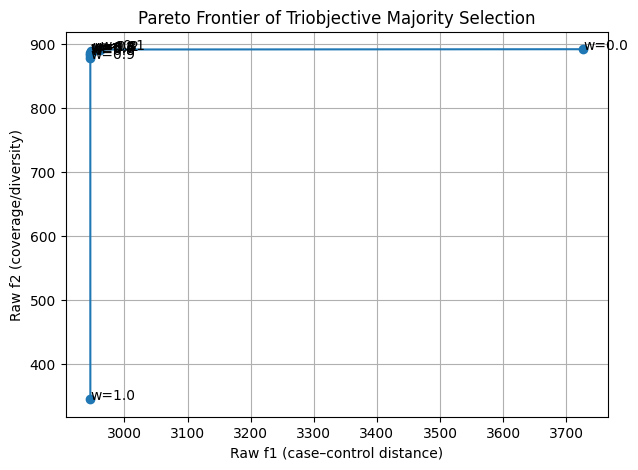

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1) f1 vs f2
axes[0].plot(all_records["f1"], all_records["f2"], marker="o")
for _, r in all_records.iterrows():
    axes[0].text(r["f1"], r["f2"], f"v={r['v']:.1f}")
axes[0].set_xlabel("f1: case–control distance")
axes[0].set_ylabel("f2: coverage")
axes[0].set_title("f1 vs f2")
axes[0].grid(True)

# 2) f1 vs f3
axes[1].plot(all_records["f1"], all_records["f3"], marker="o")
for _, r in all_records.iterrows():
    axes[1].text(r["f1"], r["f3"], f"v={r['v']:.1f}")
axes[1].set_xlabel("f1: case–control distance")
axes[1].set_ylabel("f3: dispersion")
axes[1].set_title("f1 vs f3")
axes[1].grid(True)

# 3) f2 vs f3
axes[2].plot(all_records["f2"], all_records["f3"], marker="o")
for _, r in all_records.iterrows():
    axes[2].text(r["f2"], r["f3"], f"v={r['v']:.1f}")
axes[2].set_xlabel("f2: coverage")
axes[2].set_ylabel("f3: dispersion")
axes[2].set_title("f2 vs f3")
axes[2].grid(True)

fig.suptitle("Triobjective Pareto Projections (w=0.5, varying v)", fontsize=14)
plt.tight_layout()
plt.show()


In [14]:
all_records

,w,v,f1,f2,f3
0,0.0,0.2,3862.645051,1096.424778,223389.135853
1,0.1,0.2,2895.468447,1095.849923,222891.415638
2,0.2,0.2,2879.431437,1094.042412,222970.875622
3,0.3,0.2,2871.501216,1092.240977,223250.622218
4,0.4,0.2,2864.043591,1089.535695,223610.287995
5,0.5,0.2,2862.163797,1087.856394,224240.656595
6,0.6,0.2,2860.486008,1085.737135,224857.675768
7,0.7,0.2,2859.893107,1083.442986,225704.040173
8,0.8,0.2,2859.219986,1079.146573,226896.506697
9,0.9,0.2,2858.984622,1071.920395,228266.538124


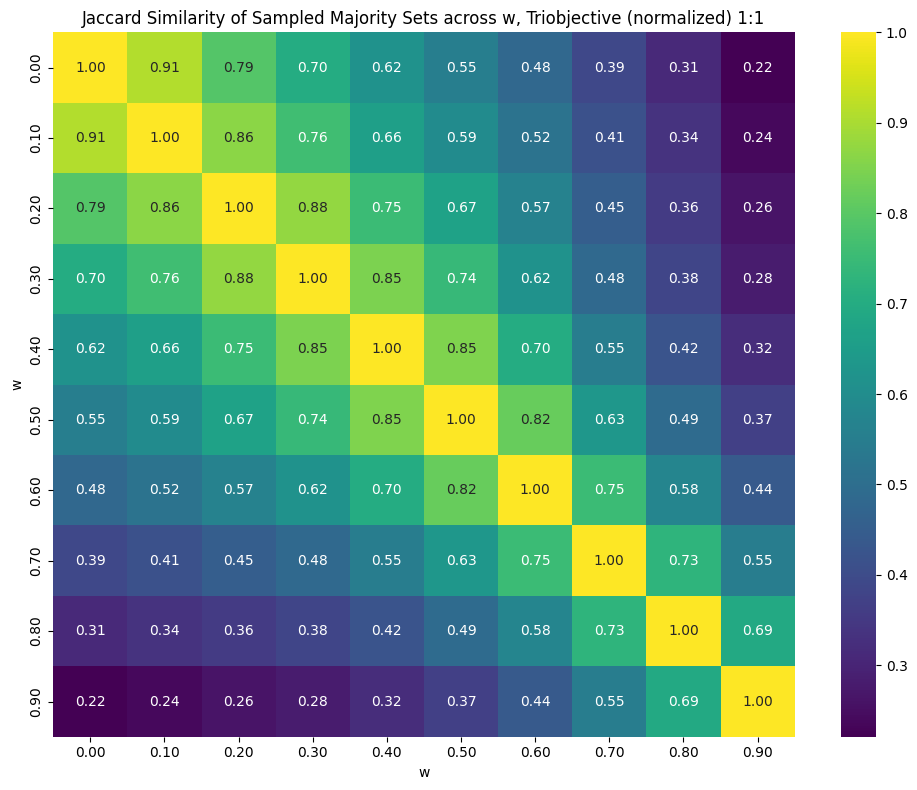

In [11]:
id_col = "ENROLID"

majority_sets = {}
results_dir = "./w_sweep_results_triobjective_normalized_"

w=0.5
for v in v_values:
    path = f"{results_dir}/undersampled_w_{w:.2f}_v_{v:.2f}.csv"
    df = pd.read_csv(path)
    # Keep only majority samples
    maj_ids = set(df.loc[df[target_col] == 0, id_col].astype(int))
    majority_sets[v] = maj_ids
jac_mat = np.zeros((len(v_values), len(v_values)))
for i, wi in enumerate(v_values):
    A = majority_sets[wi]
    for j, wj in enumerate(v_values):
        B = majority_sets[wj]
        inter = len(A & B)
        union = len(A | B)
        jac_mat[i,j] = inter / union if union > 0 else np.nan
jac_df = pd.DataFrame(
    jac_mat,
    index=[f"{w:.2f}" for w in v_values],
    columns=[f"{w:.2f}" for w in v_values]
)
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(jac_df, annot=True, fmt=".2f", cmap="viridis")
plt.title("Jaccard Similarity of Sampled Majority Sets across w, Triobjective (normalized) 1:1")
plt.xlabel("w")
plt.ylabel("w")
plt.tight_layout()
plt.show()


In [7]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct
split_seed = 42
balanced_model, balanced_params, _, preprocessor, feature_names = finetune_oct(
    X_train=train_pd[feature_cols],
    y_train=train_pd[target_col],
    X_val=X_val,
    y_val=y_val,
    categorical_cols=CAT_COLUMNS,
    numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

metrics = evaluate_binary_oct(
    balanced_model,
    X_test,
    y_test,
    preprocessor,
    feature_names
)

2025-12-04 09:35:57,566 WARNING  Interpretable AI license expires soon: 2025-12-31T00:00:00. If you need to renew, please send us the following machine ID:
da2d87f307115a4389e740fa6b3796f3ca586f217a49634cef5fb2b2945f7cea


→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', 'quarterly_max_2017', 'quarterly_min_20

┌ Warning: Interpretable AI license expires soon: 2025-12-31T00:00:00. If you need to renew, please send us the following machine ID:
└ da2d87f307115a4389e740fa6b3796f3ca586f217a49634cef5fb2b2945f7cea


Test dataset for OCT application: 5,032 samples
✓ Predictions completed
AUC score: 0.604
PR-AUC (Average Precision): 0.092
Optimal-threshold F1: 0.211 at threshold=0.132
Sensitivity (Recall): 0.234
Specificity: 0.972
Confusion Matrix:
 [[4752  139]
 [ 108   33]]
Number of leaves: 3


In [14]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct
split_seed = 42

results_dir = "./w_sweep_results_triobjective_normalized_/"
os.makedirs(results_dir, exist_ok=True)
metrics_master_path = f"{results_dir}/metrics_master.csv"

v_values = np.linspace(0.0, 0.9, 10)
w=0.5
for v in v_values:
    print("="*40)
    print(f"Loading triobjective sampling ")
    print("="*40)
    save_path = f"{results_dir}/undersampled_w_{w:.2f}_v_{v:.2f}.csv"
    undersampled_training_data = pd.read_csv(save_path)
    balanced_model, balanced_params, _, preprocessor, feature_names = finetune_oct(
        X_train=undersampled_training_data[feature_cols],
        y_train=undersampled_training_data[target_col],
        X_val=X_val,
        y_val=y_val,
        categorical_cols=CAT_COLUMNS,
        numeric_cols=TRUE_NUM_COLUMNS,
        depths=depths_M2,
        minbuckets=minbuckets_M2,
        cps=cps_M2
    )

    metrics = evaluate_binary_oct(
        balanced_model,
        X_test,
        y_test,
        preprocessor,
        feature_names
    )

    row = metrics.copy()
    row["v"] = v
    row["w"] = w

    pd.DataFrame([row]).to_csv(
        metrics_master_path,
        mode='a',
        header=not os.path.exists(metrics_master_path),
        index=False
    )

    with open(f"{results_dir}/metrics_v_{v:.2f}_w{w:.2f}.pkl", "wb") as f:
        pickle.dump(metrics, f)


Loading triobjective sampling 
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', 'quarter

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Test dataset for OCT application: 5,032 samples


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Predictions completed
AUC score: 0.799
Sensitivity (Recall): 0.631
Specificity: 0.862
Confusion Matrix:
 [[4214  677]
 [  52   89]]
PR-AUC (Average Precision): 0.104
Per-leaf metrics (top 10):
   leaf_id     n  accuracy  precision  recall        f1
6       13   382  0.141361   0.141361     1.0  0.247706
5       12   148  0.094595   0.094595     1.0  0.172840
3        9   110  0.090909   0.090909     1.0  0.166667
2        8   126  0.087302   0.087302     1.0  0.160584
0        4  3601  0.991947   0.000000     0.0  0.000000
1        7   344  0.973837   0.000000     0.0  0.000000
4       11   321  0.956386   0.000000     0.0  0.000000
Loading triobjective sampling 
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd

...

[ Warning: The type of y (Any) does not match the original target type (Int64)
/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Test dataset for OCT application: 5,032 samples


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Predictions completed
AUC score: 0.803
Sensitivity (Recall): 0.879
Specificity: 0.635
Confusion Matrix:
 [[3108 1783]
 [  17  124]]
PR-AUC (Average Precision): 0.083
Per-leaf metrics (top 10):
   leaf_id     n  accuracy  precision  recall        f1
3        7   591  0.111675   0.111675     1.0  0.200913
2        6  1316  0.044073   0.044073     1.0  0.084425
0        2  2080  0.996154   0.000000     0.0  0.000000
1        5  1045  0.991388   0.000000     0.0  0.000000


[ Warning: The type of y (Any) does not match the original target type (Int64)


# Model Comparisons

[{'auc': 0.7928761903104703, 'pr_auc': np.float64(0.1025728565435318), 'sensitivity': np.float64(0.6879432624113475), 'specificity': np.float64(0.8333674095277039), 'tp': np.int64(97), 'fp': np.int64(815), 'fn': np.int64(44), 'tn': np.int64(4076), 'v': 0.2, 'w': 0.5}, {'auc': 0.8073244967236102, 'pr_auc': np.float64(0.08145734082772875), 'sensitivity': np.float64(0.8439716312056738), 'specificity': np.float64(0.7227560826006951), 'tp': np.int64(119), 'fp': np.int64(1356), 'fn': np.int64(22), 'tn': np.int64(3535), 'v': 0.7, 'w': 0.5}, {'auc': 0.7991070587024075, 'pr_auc': np.float64(0.10448533680848929), 'sensitivity': np.float64(0.6312056737588653), 'specificity': np.float64(0.8615824984665712), 'tp': np.int64(89), 'fp': np.int64(677), 'fn': np.int64(52), 'tn': np.int64(4214), 'v': 0.0, 'w': 0.5}, {'auc': 0.8173646486309345, 'pr_auc': np.float64(0.09560087503240247), 'sensitivity': np.float64(0.7801418439716312), 'specificity': np.float64(0.7773461459824167), 'tp': np.int64(110), 'fp':

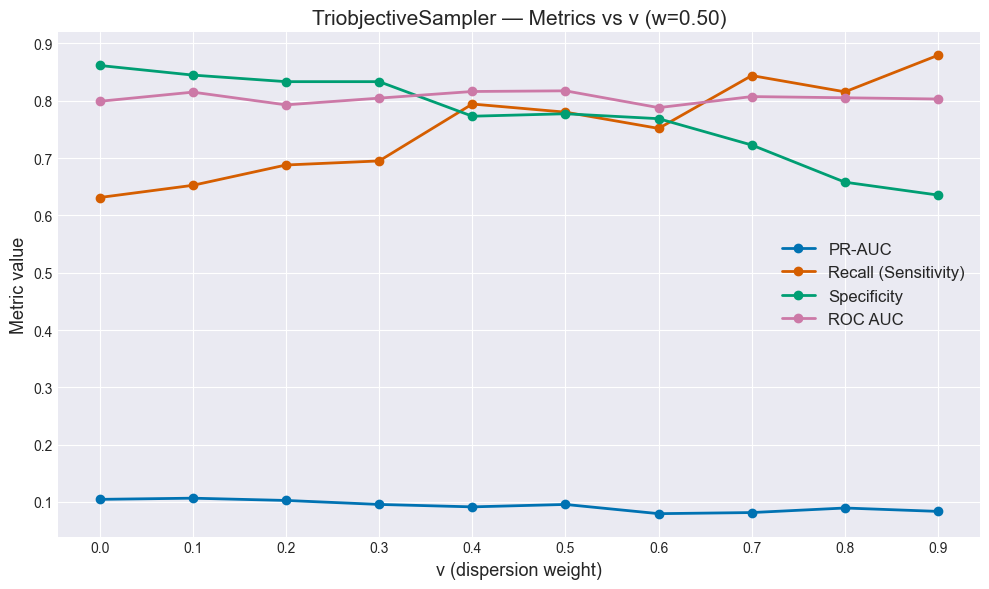

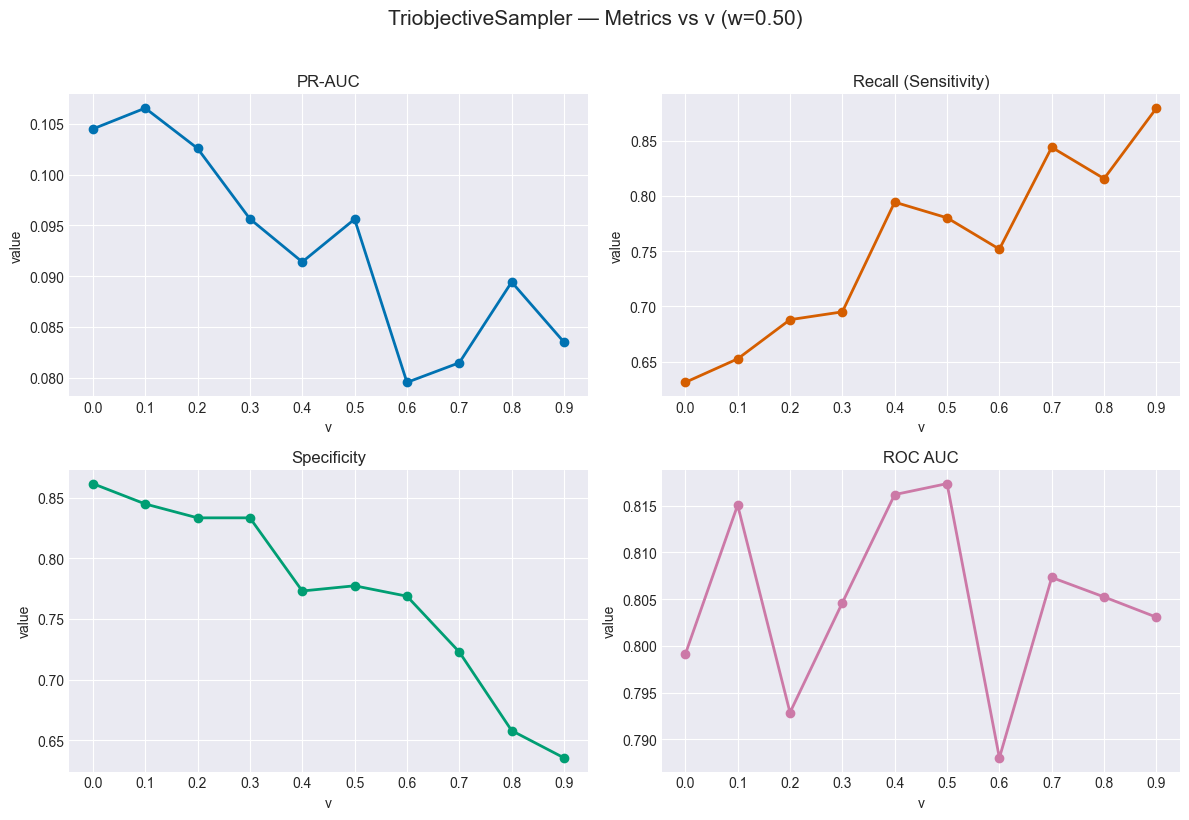

In [22]:
import re, os, pickle
import matplotlib.pyplot as plt
import pandas as pd

pattern = re.compile(r"metrics_v_([0-9.]+)_w([0-9.]+)\.pkl")
records = []

for fname in os.listdir(results_dir):
    m = pattern.match(fname)
    if m is None:
        continue

    v = float(m.group(1))
    w = float(m.group(2))

    path = os.path.join(results_dir, fname)
    with open(path, "rb") as f:
        metrics = pickle.load(f)

    metrics = metrics.copy()
    metrics["v"] = v
    metrics["w"] = w

    metrics.pop("leaf_metrics", None)

    records.append(metrics)
print(records)
df = pd.DataFrame(records).sort_values(["v"]).reset_index(drop=True)

plt.style.use("seaborn-v0_8-darkgrid")

metrics_to_plot = ["pr_auc", "sensitivity", "specificity", "auc"]
titles = ["PR-AUC", "Recall (Sensitivity)", "Specificity", "ROC AUC"]
colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

# ---------- Combined plot ----------
plt.figure(figsize=(10, 6))
for metric, title, c in zip(metrics_to_plot, titles, colors):
    plt.plot(df["v"], df[metric], marker="o", linewidth=2, label=title, color=c)

plt.xlabel("v (dispersion weight)", fontsize=13)
plt.ylabel("Metric value", fontsize=13)
plt.title(f"TriobjectiveSampler — Metrics vs v (w={df['w'].iloc[0]:.2f})", fontsize=15)
plt.legend(fontsize=12)
plt.xticks(df["v"])
plt.tight_layout()
plt.show()

# ---------- 4 subplots ----------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, metric, title, c in zip(axes, metrics_to_plot, titles, colors):
    ax.plot(df["v"], df[metric], marker="o", color=c, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("v")
    ax.set_ylabel("value")
    ax.set_xticks(df["v"])
    ax.grid(True)

fig.suptitle(f"TriobjectiveSampler — Metrics vs v (w={df['w'].iloc[0]:.2f})", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
